# Exercise 2 — Multi-Sensor Target Tracking with an Extended Kalman Filter

**Course:** Autonomous Marine Robotics  
**Topic:** Target Tracking — Radar + Camera Sensor Fusion

---

## Background

In Exercise 1 you implemented a radar-only EKF tracker. A single sensor, however, has inherent limitations:

| Sensor | Strengths | Weaknesses |
|--------|-----------|------------|
| **Radar** | Long range, all-weather, accurate range | Poor bearing resolution at long range |
| **Camera** | Excellent angular resolution, cheap | No direct range measurement; affected by visibility |

Combining both sensors inside a single EKF exploits their **complementary properties** — the radar constrains range while the camera constrains bearing — and yields a tracker that outperforms either sensor alone.

In this exercise you will implement **two** fusion architectures and compare them:

1. **Centralised (joint) update** — stack the radar and camera measurements into a single vector and perform one EKF update.
2. **Sequential update** — apply the radar update, then the camera update in separate EKF update steps at the same time instant.

You will then analyse when the two architectures are equivalent and discuss practical trade-offs for embedded marine systems.

---

## Learning Objectives

1. Extend a single-sensor EKF to fuse measurements from two heterogeneous sensors.
2. Implement and understand the **centralised** and **sequential** fusion architectures.
3. Assess the **benefit of sensor fusion** quantitatively using RMSE and NIS.
4. Identify and handle **sensor asynchrony** (sensors arriving at different rates).
5. Reason about sensor failure modes and filter robustness.

---

## Scenario

Same target and ownship as Exercise 1. Sensor configuration:

| Parameter | Value |
|-----------|-------|
| Radar scan rate | 1 Hz — measures $(r, \phi)$ |
| Camera frame rate | 1 Hz (synchronised) — measures **bearing only** $\phi_c$ |
| $\sigma_r$ | 10 m |
| $\sigma_\phi$ (radar) | 0.5° = 0.00873 rad |
| $\sigma_{\phi_c}$ (camera) | **0.1°** = 0.00175 rad |

> The camera has **5× better bearing accuracy** than the radar. This difference will be exploited by the fusion filter.

---

## Prerequisite

This notebook builds on Exercise 1. The functions `build_motion_model`, `h_radar`, `H_jacobian_radar`, `build_R_radar`, `ekf_predict`, `ekf_update_radar`, and `wrap_angle` are imported below. **Make sure Exercise 1 is complete and saved before running this notebook**, or copy the implementations into the cell marked `# ── Exercise-1 imports ──`.

---

## Section 0 — Imports and Shared Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from scipy.stats import chi2

np.random.seed(42)

# ── Simulation parameters ──────────────────────────────────────────────────
dt      = 1.0
T_total = 120
N       = int(T_total / dt)

x0_true = np.array([-300.0, 200.0, 3.0, 1.5])

# ── Noise parameters ───────────────────────────────────────────────────────
sigma_r      = 10.0
sigma_phi_r  = np.deg2rad(0.5)    # radar bearing std
sigma_phi_c  = np.deg2rad(0.1)    # camera bearing std  ← finer!
sigma_a      = 0.1

print(f"Camera bearing std:  {np.rad2deg(sigma_phi_c):.3f} deg")
print(f"Radar  bearing std:  {np.rad2deg(sigma_phi_r):.3f} deg")
print(f"Bearing improvement: {sigma_phi_r/sigma_phi_c:.1f}×")

Camera bearing std:  0.100 deg
Radar  bearing std:  0.500 deg
Bearing improvement: 5.0×


In [ ]:
# ── Exercise-1 implementations ──────────────────────────────────────────────
# Paste your completed functions from Exercise 1 here, OR
# uncomment the import below if you saved Exercise 1 as ex1_solution.py:
# from ex1_solution import (build_motion_model, h_radar, H_jacobian_radar,
#                            build_R_radar, ekf_predict, ekf_update_radar, wrap_angle)

# --- paste / implement here ---

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def build_motion_model(dt: float, sigma_a: float):
    F = np.array([[1, 0, dt, 0],
                  [0, 1,  0, dt],
                  [0, 0,  1,  0],
                  [0, 0,  0,  1]], dtype=float)

    q  = sigma_a ** 2
    dt2 = dt ** 2
    dt3 = dt ** 3
    dt4 = dt ** 4
    Q = q * np.array([[dt4 / 4,       0, dt3 / 2,       0],
                       [      0, dt4 / 4,       0, dt3 / 2],
                       [dt3 / 2,       0,     dt2,       0],
                       [      0, dt3 / 2,       0,     dt2]])
    return F, Q


def h_radar(x: np.ndarray) -> np.ndarray:
    px, py = x[0], x[1]
    r   = np.sqrt(px**2 + py**2)   # range
    phi = np.arctan2(py, px)        # bearing
    return np.array([r, phi])


def H_jacobian_radar(x: np.ndarray) -> np.ndarray:
    px, py = x[0], x[1]
    r2 = px**2 + py**2   # r squared
    r  = np.sqrt(r2)      # r

    H = np.zeros((2, 4))
    H[0, 0] =  px / r
    H[0, 1] =  py / r
    H[1, 0] = -py / r2
    H[1, 1] =  px / r2
    return H


def build_R_radar(sigma_r: float, sigma_phi: float) -> np.ndarray:
    return np.diag([sigma_r**2, sigma_phi**2])


def ekf_predict(x: np.ndarray, P: np.ndarray, F: np.ndarray, Q: np.ndarray):
    x_pred = F @ x
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred


def ekf_update_radar(x_pred: np.ndarray, P_pred: np.ndarray,
                     z: np.ndarray, R: np.ndarray):
    H = H_jacobian_radar(x_pred)
    z_pred = h_radar(x_pred)
    innov    = z - z_pred
    innov[1] = wrap_angle(innov[1])
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ inv(S)
    x_upd = x_pred + K @ innov
    I     = np.eye(len(x_pred))
    IKH   = I - K @ H
    P_upd = IKH @ P_pred @ IKH.T + K @ R @ K.T

    return x_upd, P_upd, innov, S


# Build shared matrices
F, Q = build_motion_model(dt, sigma_a)
R_radar = build_R_radar(sigma_r, sigma_phi_r)
print("Motion model and radar noise matrices ready.")

Motion model and radar noise matrices ready.


---

## Section 1 — Camera Measurement Model

The on-board camera measures the **bearing angle** to the target — the same quantity as the radar bearing, but with substantially lower noise. The camera measurement model is:

$$
h_c(\mathbf{x}) = \text{atan2}(p_y,\, p_x), \qquad R_c = \sigma_{\phi_c}^2
$$

The Jacobian is the second row of $\mathbf{H}_{\text{radar}}$:

$$
\mathbf{H}_c = \begin{bmatrix} -\dfrac{p_y}{r^2} & \dfrac{p_x}{r^2} & 0 & 0 \end{bmatrix}, \quad r = \sqrt{p_x^2 + p_y^2}
$$

### ✏️ Task 1.1 — Implement the camera measurement model

In [ ]:
def h_camera(x: np.ndarray) -> float:
    """
    Camera measurement function: bearing angle to the target.

    Parameters
    ----------
    x : (4,) ndarray  — state [px, py, vx, vy]

    Returns
    -------
    phi_c : float  — predicted bearing [rad]
    """
    px, py = x[0], x[1]
    return np.arctan2(py, px)


def H_jacobian_camera(x: np.ndarray) -> np.ndarray:
    """
    Jacobian of h_camera with respect to x.

    Returns
    -------
    H_c : (1, 4) ndarray
    """
    px, py = x[0], x[1]
    r2 = px**2 + py**2   # r squared

    H = np.zeros((1, 4))
    H[0, 0] =  -py / r2
    H[0, 1] =  px / r2
    return H


def build_R_camera(sigma_phi_c: float) -> np.ndarray:
    """Measurement noise covariance for camera (1×1 matrix)."""
    return np.array([[sigma_phi_c**2]])


# Quick sanity check
x_test   = np.array([100.0, 100.0, 2.0, 0.5])
phi_test = h_camera(x_test)
H_c_test = H_jacobian_camera(x_test)
R_cam    = build_R_camera(sigma_phi_c)

print(f"h_camera([100, 100, ...]) = {phi_test:.4f} rad  (expected: {np.deg2rad(45):.4f})")
print(f"H_c = {H_c_test}")
print(f"R_camera = {R_cam}")

h_camera([100, 100, ...]) = 0.7854 rad  (expected: 0.7854)
H_c = [[-0.005  0.005  0.     0.   ]]
R_camera = [[3.0461742e-06]]


---

## Section 2 — Simulate Measurements from Both Sensors

In [ ]:
def simulate_trajectory(x0, F, N):
    xs = np.zeros((N + 1, 4))
    xs[0] = x0
    for k in range(N):
        xs[k + 1] = F @ xs[k]
    return xs


def simulate_radar_measurements(xs, sigma_r, sigma_phi):
    zs = np.zeros((len(xs), 2))
    for k, x in enumerate(xs):
        r   = np.sqrt(x[0]**2 + x[1]**2)
        phi = np.arctan2(x[1], x[0])
        zs[k] = [r   + np.random.randn() * sigma_r,
                 phi + np.random.randn() * sigma_phi]
    return zs


def simulate_camera_measurements(xs, sigma_phi_c):
    """Camera returns bearing-only measurements."""
    zs_c = np.zeros(len(xs))
    for k, x in enumerate(xs):
        phi_true = np.arctan2(x[1], x[0])
        zs_c[k]  = phi_true + np.random.randn() * sigma_phi_c
    return zs_c


xs_true  = simulate_trajectory(x0_true, F, N)
zs_radar = simulate_radar_measurements(xs_true[1:], sigma_r, sigma_phi_r)
zs_cam   = simulate_camera_measurements(xs_true[1:], sigma_phi_c)

print(f"Radar measurements:  {zs_radar.shape}")
print(f"Camera measurements: {zs_cam.shape}")

Radar measurements:  (120, 2)
Camera measurements: (120,)


---

## Section 3 — Fusion Architecture A: Sequential Update

In the **sequential update** architecture, each sensor's measurement is applied as a separate EKF update using the posterior from the previous update as the new prior:

$$
\underbrace{(\hat{\mathbf{x}}_k^-, \mathbf{P}_k^-)}_\text{prediction}
\xrightarrow{\text{radar update}}
\underbrace{(\hat{\mathbf{x}}_k^{(1)}, \mathbf{P}_k^{(1)})}_\text{after radar}
\xrightarrow{\text{camera update}}
\underbrace{(\hat{\mathbf{x}}_k, \mathbf{P}_k)}_\text{final posterior}
$$

This is equivalent to the centralised update **when the sensor noises are uncorrelated** (which they are here). It is often preferred in practice because each individual update step is smaller and easier to debug.

### ✏️ Task 3.1 — Implement the camera EKF update step

In [ ]:
def ekf_update_camera(x_pred: np.ndarray, P_pred: np.ndarray,
                      z_c: float, R_c: np.ndarray):
    """
    EKF update step for a camera bearing measurement.

    Parameters
    ----------
    x_pred : (4,)   predicted (or intermediate) state
    P_pred : (4,4)  predicted (or intermediate) covariance
    z_c    : float  camera bearing measurement [rad]
    R_c    : (1,1)  camera measurement noise covariance

    Returns
    -------
    x_upd : (4,)   updated state estimate
    P_upd : (4,4)  updated covariance
    innov : float  bearing innovation [rad]
    S_c   : (1,1)  innovation covariance
    """
    # TODO: implement the EKF update for a scalar bearing measurement
    # Hint: follow the same 7-step structure as ekf_update_radar,
    # but H is (1×4) and S, K, innovation are scalar/1D.
    # Don't forget to wrap the bearing innovation!

    H_c    = H_jacobian_camera(x_pred)  # (1, 4) Jacobian
    z_pred = h_camera(x_pred)  # scalar predicted bearing
    innov = wrap_angle(z_c - z_pred)  # scalar innovation  (wrap!)
    S_c    = H_c @ P_pred @ H_c.T + R_c # (1, 1) innovation covariance
    K      = P_pred @ H_c.T @ inv(S_c)  # (4, 1) Kalman gain
    x_upd = x_pred + (K * innov).reshape(-1)  # (4,)
    I     = np.eye(len(x_pred))
    IKH   = I - K @ H_c
    P_upd = IKH @ P_pred @ IKH.T + K @ R_c @ K.T  # (4, 4) — use Joseph form
    return x_upd, P_upd, innov, S_c


### ✏️ Task 3.2 — Run the sequential fusion EKF

In [ ]:
# ── Initialisation ─────────────────────────────────────────────────────────
r0, phi0 = zs_radar[0]
x_init   = np.array([r0 * np.cos(phi0), r0 * np.sin(phi0), 0.0, 0.0])
P_init   = np.diag([sigma_r**2, sigma_r**2, 50.0**2, 50.0**2])
R_cam    = build_R_camera(sigma_phi_c)

# ── Storage ────────────────────────────────────────────────────────────────
x_seq   = np.zeros((N, 4))
P_seq   = np.zeros((N, 4, 4))

x = x_init.copy()
P = P_init.copy()

for k in range(N):
    # Step 1: Predict
    x, P = ekf_predict(x, P, F, Q)

    # Step 2: Radar update
    # TODO: call ekf_update_radar with zs_radar[k]
    # --- your code here ---
    x, P, innov_radar, S_radar = ekf_update_radar(x, P, zs_radar[k], R_radar)


    # Step 3: Camera update (bearing only)
    # TODO: call ekf_update_camera with zs_cam[k]
    # --- your code here ---
    x, P, innov_cam, S_cam = ekf_update_camera(x, P, zs_cam[k], R_cam)


    x_seq[k] = x
    P_seq[k] = P

print("Sequential fusion EKF complete.")

Sequential fusion EKF complete.


---

## Section 4 — Fusion Architecture B: Centralised (Joint) Update

In the **centralised update**, the measurements from both sensors are **stacked** into a single vector and processed in one update step:

$$
\mathbf{z}_k = \begin{bmatrix} r \\ \phi_{\text{radar}} \\ \phi_{\text{camera}} \end{bmatrix},
\quad
\mathbf{h}(\mathbf{x}) = \begin{bmatrix} h_{\text{radar}}(\mathbf{x}) \\ h_c(\mathbf{x}) \end{bmatrix},
\quad
\mathbf{R} = \begin{bmatrix} \sigma_r^2 & 0 & 0 \\ 0 & \sigma_\phi^2 & 0 \\ 0 & 0 & \sigma_{\phi_c}^2 \end{bmatrix}
$$

The combined Jacobian is:

$$
\mathbf{H}_{\text{joint}} = \begin{bmatrix} \mathbf{H}_{\text{radar}} \\ \mathbf{H}_c \end{bmatrix} \in \mathbb{R}^{3 \times 4}
$$

### ✏️ Task 4.1 — Implement the joint measurement update

In [ ]:
def ekf_update_joint(x_pred: np.ndarray, P_pred: np.ndarray,
                     z_r: np.ndarray, z_c: float,
                     R_radar: np.ndarray, R_cam: np.ndarray):
    """
    EKF joint update using a stacked radar + camera measurement vector.

    Parameters
    ----------
    x_pred  : (4,)   predicted state
    P_pred  : (4,4)  predicted covariance
    z_r     : (2,)   radar measurement [range, bearing_radar]
    z_c     : float  camera bearing measurement
    R_radar : (2,2)  radar noise covariance
    R_cam   : (1,1)  camera noise covariance

    Returns
    -------
    x_upd : (4,)   updated state
    P_upd : (4,4)  updated covariance
    innov : (3,)   joint innovation vector
    S     : (3,3)  joint innovation covariance
    """
    # TODO step 1: build the joint measurement vector z_joint (3,)
    z_joint = np.hstack([z_r, z_c])

    # TODO step 2: build the joint predicted measurement h_joint (3,)
    h_joint = np.hstack([h_radar(x_pred), h_camera(x_pred)])

    # TODO step 3: build the joint Jacobian H_joint (3×4)
    #              stack H_radar and H_camera vertically
    H_joint = np.vstack([H_jacobian_radar(x_pred), H_jacobian_camera(x_pred)])

    # TODO step 4: build the block-diagonal joint noise covariance R_joint (3×3)
    R_joint = R_joint = np.block([[R_radar, np.zeros((2,1))],[np.zeros((1,2)), R_cam]])

    # TODO step 5: compute innovation, wrap BOTH bearing components
    innov = z_joint - h_joint
    innov[1] = wrap_angle(innov[1])  # radar bearing
    innov[2] = wrap_angle(innov[2])  # camera bearing

    # TODO step 6: innovation covariance S (3×3)
    S = H_joint @ P_pred @ H_joint.T + R_joint

    # TODO step 7: Kalman gain K (4×3)
    K = P_pred @ H_joint.T @ np.linalg.inv(S)

    # TODO step 8: updated state (4,)
    x_upd = x_pred + K @ innov

    # TODO step 9: updated covariance — Joseph form
    I = np.eye(4)
    IKH = I - K @ H_joint
    P_upd = IKH @ P_pred @ IKH.T + K @ R_joint @ K.T

    return x_upd, P_upd, innov, S

### ✏️ Task 4.2 — Run the centralised fusion EKF

In [ ]:
# ── Initialisation (same as sequential) ───────────────────────────────────
x = x_init.copy()
P = P_init.copy()

x_cen   = np.zeros((N, 4))
P_cen   = np.zeros((N, 4, 4))
innov_cen = np.zeros((N, 3))
S_cen     = np.zeros((N, 3, 3))

for k in range(N):
    # Step 1: Predict
    x, P = ekf_predict(x, P, F, Q)

    # Step 2: Joint update
    # TODO: call ekf_update_joint
    # --- your code here ---
    x, P, innov, S = ekf_update_joint(x, P,
                                      zs_radar[k],
                                      zs_cam[k],
                                      R_radar,
                                      R_cam
                                  )

    x_cen[k]     = x
    P_cen[k]     = P
    # innov_cen[k] = innov  # uncomment once implemented
    # S_cen[k]     = S

print("Centralised fusion EKF complete.")

Centralised fusion EKF complete.


---

## Section 5 — Baseline: Radar-Only EKF (from Exercise 1)

Reproduce the Exercise 1 tracker so we can compare all three.

In [ ]:
# ── Radar-only baseline ────────────────────────────────────────────────────
x = x_init.copy()
P = P_init.copy()

x_radar_only = np.zeros((N, 4))
P_radar_only = np.zeros((N, 4, 4))

for k in range(N):
    x, P = ekf_predict(x, P, F, Q)
    x, P, _, _ = ekf_update_radar(x, P, zs_radar[k], R_radar)
    x_radar_only[k] = x
    P_radar_only[k] = P

print("Radar-only baseline complete.")

Radar-only baseline complete.


---

## Section 6 — Comparative Performance Evaluation

### ✏️ Task 6.1 — Compute RMSE for all three trackers and plot

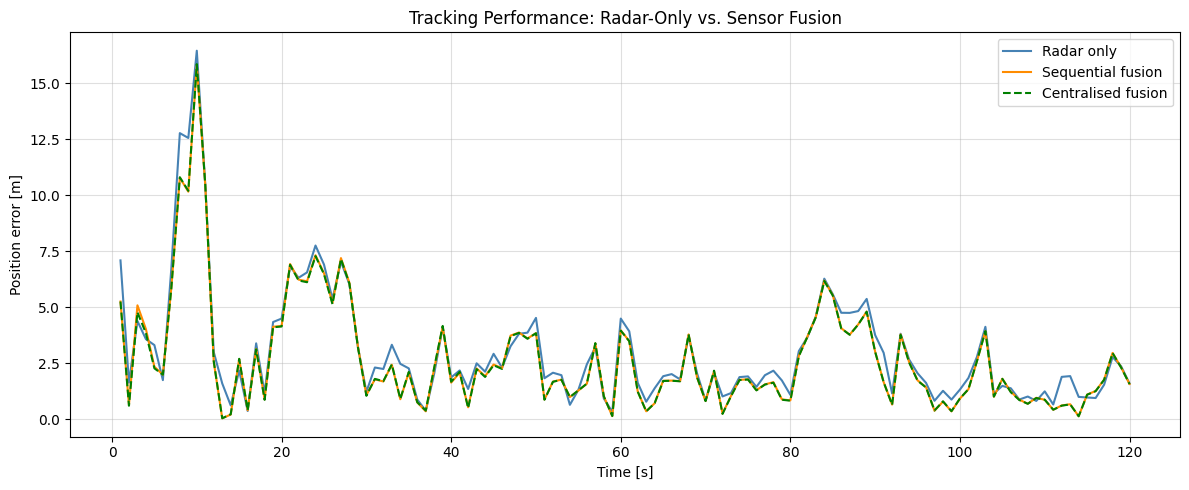


Overall position RMSE:
  Radar only:          3.97 m
  Sequential fusion:   3.66 m
  Centralised fusion:  3.65 m


In [ ]:
def position_rmse_over_time(x_est, xs_true):
    """Per-step position error (not cumulative RMSE)."""
    return np.sqrt((x_est[:, 0] - xs_true[1:, 0])**2 +
                   (x_est[:, 1] - xs_true[1:, 1])**2)


err_radar = position_rmse_over_time(x_radar_only, xs_true)
err_seq   = position_rmse_over_time(x_seq, xs_true)
err_cen   = position_rmse_over_time(x_cen, xs_true)

t = np.arange(1, N + 1) * dt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, err_radar, 'steelblue',  lw=1.5, label='Radar only')
ax.plot(t, err_seq,   'darkorange', lw=1.5, label='Sequential fusion')
ax.plot(t, err_cen,   'green',      lw=1.5, ls='--', label='Centralised fusion')
ax.set_xlabel('Time [s]');  ax.set_ylabel('Position error [m]')
ax.set_title('Tracking Performance: Radar-Only vs. Sensor Fusion')
ax.legend();  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

# Summary table
print("\nOverall position RMSE:")
print(f"  Radar only:          {np.sqrt(np.mean(err_radar**2)):.2f} m")
print(f"  Sequential fusion:   {np.sqrt(np.mean(err_seq**2)):.2f} m")
print(f"  Centralised fusion:  {np.sqrt(np.mean(err_cen**2)):.2f} m")

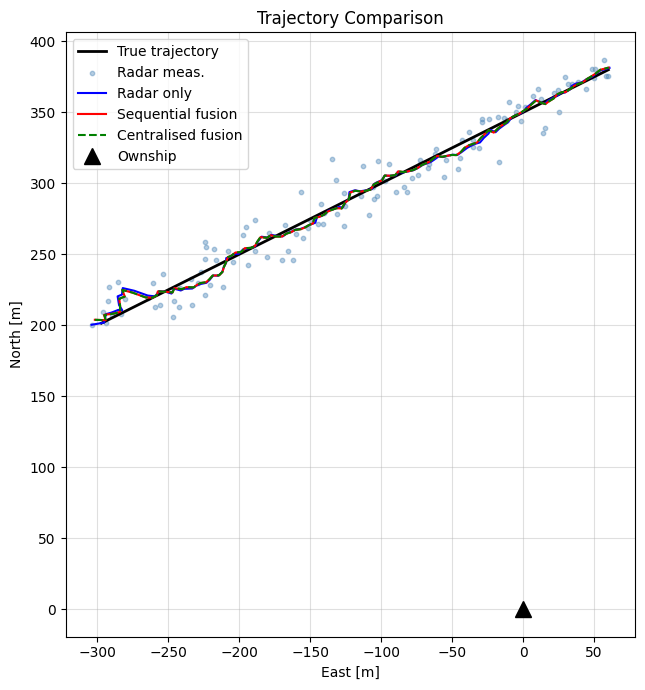

In [ ]:
# ── Trajectory plot: all three trackers ──────────────────────────────────
meas_x = zs_radar[:, 0] * np.cos(zs_radar[:, 1])
meas_y = zs_radar[:, 0] * np.sin(zs_radar[:, 1])

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(xs_true[1:, 0], xs_true[1:, 1], 'k-',    lw=2,       label='True trajectory')
ax.scatter(meas_x, meas_y, s=10, c='steelblue',   alpha=0.4,  label='Radar meas.')
ax.plot(x_radar_only[:, 0], x_radar_only[:, 1], 'b-',         label='Radar only')
ax.plot(x_seq[:, 0],  x_seq[:, 1],  'r-',   lw=1.5,          label='Sequential fusion')
ax.plot(x_cen[:, 0],  x_cen[:, 1],  'g--',  lw=1.5,          label='Centralised fusion')
ax.plot(0, 0, 'k^', ms=12, label='Ownship')
ax.set_xlabel('East [m]');  ax.set_ylabel('North [m]')
ax.set_title('Trajectory Comparison')
ax.legend();  ax.set_aspect('equal');  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

---

## Section 7 — NIS for the Centralised Filter

For the centralised filter, the joint innovation has **3 degrees of freedom** (range + 2 bearings).

### ✏️ Task 7.1 — Compute and plot the NIS for the centralised filter

In [ ]:
nz    = 3
lower = chi2.ppf(0.025, df=nz)
upper = chi2.ppf(0.975, df=nz)

# TODO: compute NIS for each step using innov_cen and S_cen
nis_cen = np.zeros(N)
for k in range(N):
  y = innov_cen[k]       # (3,)
  S = S_cen[k]           # (3,3)
  print("First S:", S_cen[0])
  print("First innov:", innov_cen[0])
  print("R_radar:", R_radar)
  print("R_cam:", R_cam)
  nis_cen[k] = y @ np.linalg.solve(S, y)

frac = np.mean((nis_cen >= lower) & (nis_cen <= upper))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, nis_cen, '.', ms=4, alpha=0.7)
ax.axhline(upper, color='r', ls='--', label=f'95% upper ({upper:.2f})')
ax.axhline(lower, color='g', ls='--', label=f'95% lower ({lower:.2f})')
ax.set_title(f'NIS — Centralised Fusion  ({frac*100:.1f}% within bounds)')
ax.set_xlabel('Time [s]');  ax.set_ylabel('NIS')
ax.legend();  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

First S: [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
First innov: [0. 0. 0.]
R_radar: [[1.00000000e+02 0.00000000e+00]
 [0.00000000e+00 7.61543549e-05]]
R_cam: [[3.0461742e-06]]


LinAlgError: Singular matrix

---

## Section 8 — Sensor Dropout Experiment

Real sensors occasionally fail (rain, obstruction, hardware faults). In this section you will simulate a **camera dropout** lasting 20 seconds and observe how the tracker degrades and recovers.

### ✏️ Task 8.1 — Implement the sequential EKF with conditional camera update

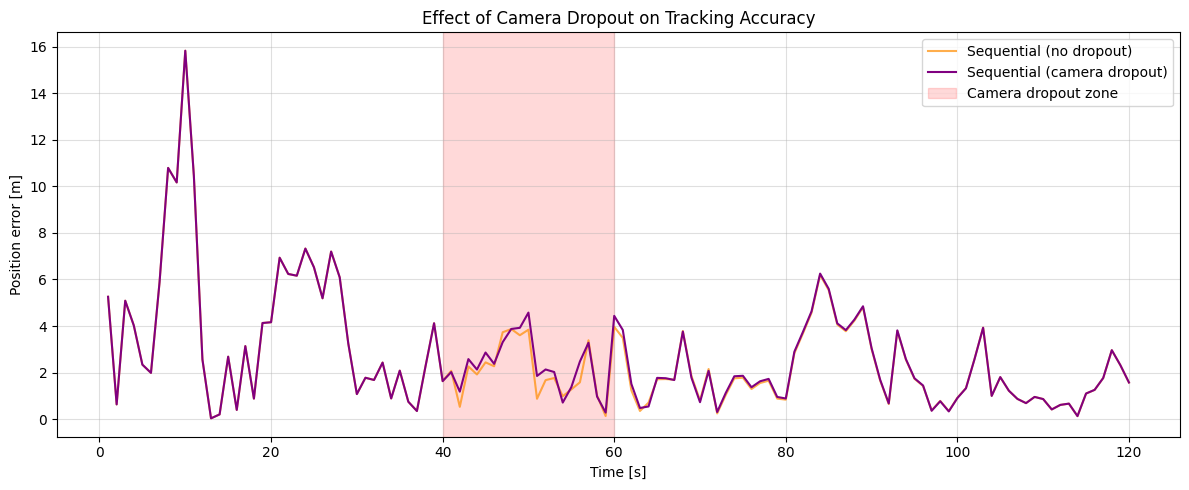

In [ ]:
# Camera is unavailable during steps 40–59 (seconds 40–59)
DROPOUT_START = 40
DROPOUT_END   = 60  # exclusive

x = x_init.copy()
P = P_init.copy()

x_dropout = np.zeros((N, 4))

for k in range(N):
    # Predict
    x, P = ekf_predict(x, P, F, Q)

    # Always update with radar
    x, P, _, _ = ekf_update_radar(x, P, zs_radar[k], R_radar)

    # TODO: update with camera ONLY if not in dropout window
    camera_available = not (DROPOUT_START <= k < DROPOUT_END)
    if camera_available:
        x, P, innov_cam, S_cam = ekf_update_camera(x, P, zs_cam[k], R_cam)

    x_dropout[k] = x

# ── Plot ─────────────────────────────────────────────────────────────────
err_dropout = position_rmse_over_time(x_dropout, xs_true)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, err_seq,     'darkorange', lw=1.5, alpha=0.7, label='Sequential (no dropout)')
ax.plot(t, err_dropout, 'purple',     lw=1.5,            label='Sequential (camera dropout)')
ax.axvspan(DROPOUT_START, DROPOUT_END, alpha=0.15, color='red', label='Camera dropout zone')
ax.set_xlabel('Time [s]');  ax.set_ylabel('Position error [m]')
ax.set_title('Effect of Camera Dropout on Tracking Accuracy')
ax.legend();  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

---

## Section 9 — Asynchronous Sensor Rates (Extension Task)

In practice, the camera may run at a **higher frame rate** than the radar. In this extension, the camera runs at **5 Hz** while the radar remains at **1 Hz**.

The key idea is that between radar scans, we still predict and apply camera updates:

```
k=0: [predict 0.2s] [camera update] [predict 0.2s] [camera] ... [predict 0.2s] [camera] [radar update]
```

### ✏️ Task 9.1 — Implement the asynchronous fusion loop

In [ ]:
# Camera at 5 Hz → 5 camera measurements per radar scan
dt_cam      = 0.2         # camera time step [s]
cam_per_scan = 5          # camera frames per radar scan

# Build a finer motion model for the camera prediction step
F_cam, Q_cam = build_motion_model(dt_cam, sigma_a)

# Simulate 5 Hz camera measurements (use same true trajectory, interpolated)
N_cam_total = N * cam_per_scan
# Build a fine-grained true trajectory for camera simulation
xs_fine = simulate_trajectory(x0_true, F_cam, N_cam_total)
zs_cam_fast = simulate_camera_measurements(xs_fine[1:], sigma_phi_c)

# ── TODO: Implement the asynchronous EKF loop ────────────────────────────
x = x_init.copy()
P = P_init.copy()
x_async = np.zeros((N, 4))

for k in range(N):              # for each radar scan (1 Hz)
    for j in range(cam_per_scan):  # for each camera frame within the scan
        cam_idx = k * cam_per_scan + j

        # TODO: predict forward by dt_cam using F_cam, Q_cam
        x, P = ekf_predict(x, P, F_cam, Q_cam)

        # TODO: apply camera update
        x, P, _, _ = ekf_update_camera(x, P, zs_cam_fast[cam_idx], R_cam)

    # After the camera loop, apply the radar update (1 Hz)
    # TODO: call ekf_update_radar with zs_radar[k]
    x, P, _, _ = ekf_update_radar(x, P, zs_radar[k], R_radar)

    x_async[k] = x

err_async = position_rmse_over_time(x_async, xs_true)
print(f"Asynchronous (5 Hz cam) RMSE: {np.sqrt(np.mean(err_async**2)):.2f} m")
print(f"Sequential   (1 Hz cam) RMSE: {np.sqrt(np.mean(err_seq**2)):.2f} m")

Asynchronous (5 Hz cam) RMSE: 3.15 m
Sequential   (1 Hz cam) RMSE: 3.66 m


---

## Section 10 — Analysis Questions

### Q1 — Equivalence of sequential and centralised updates

Under what mathematical condition are the sequential and centralised updates **exactly equivalent**? Does that condition hold here? Verify your answer numerically by comparing `x_seq` and `x_cen` element-by-element.

In [ ]:
# TODO: compute max absolute difference between x_seq and x_cen
max_diff = None  # replace
print(f"Max state difference (sequential vs centralised): {max_diff}")

**Answer Q1:** *(write here)*

---

### Q2 — Bearing-only observability

The camera provides only bearing measurements. Would a **camera-only** EKF (no radar, bearing only) be able to track the target's range? Justify your answer in terms of filter observability. Try implementing it and comment on the results.

In [ ]:
# TODO (optional): implement and run a camera-only EKF
# What happens to the range component of the estimate?
# --- your code here ---

**Answer Q2:** *(write here)*

---

### Q3 — Practical sensor fusion design

You are designing the perception stack for an autonomous surface vessel. The vessel carries radar and a stereo camera (which can estimate range up to 150 m). Beyond 150 m, the stereo camera provides bearing only. Describe how you would modify the EKF update logic to handle this **range-dependent sensor capability** gracefully.

**Answer Q3:** *(write here)*

---

### Q4 — Architecture trade-offs for embedded systems

The vessel's onboard computer is severely compute-limited. Compare the **computational cost** (matrix sizes and inversions) of the sequential vs. centralised update as the number of sensors $M$ grows. Which architecture would you recommend for an embedded marine system with $M = 6$ sensors? Justify your recommendation.